# 1 - Treino inicial da GAIN

## Objetivo

Treinar o **modelo GAIN inicial** com os hiperparâmetros padrão da literatura (Yoon et al., ICML 2018) e estabelecer o pipeline de treinamento completo: tensores, loop adversarial, curva de validação, checkpoint.

> **Pergunta que responde:** a implementação está correta e converge? Já bate algum baseline antes de qualquer ajuste fino?

## Posição na Etapa 4

Notebook **1 de 3**. Pré-requisito: `gain.py` (este diretório) com `Generator`, `Discriminator`, `generate_hint`, `train_gain` e `impute`. O ajuste fino fica para `02_hyperparam.ipynb`; o diagnóstico do melhor modelo, para `03_diagnostico.ipynb`.

## A arquitetura em dois parágrafos

O **gerador** recebe o vetor com as células faltantes preenchidas por ruído e a máscara que diz o que é real, e devolve uma reconstrução completa. Formalmente, com $\tilde{X} = M_{ef} \odot X + (1 - M_{ef}) \odot Z$ (onde $Z \sim U(-0{,}01,\ 0{,}01)$ e $M_{ef}$ é a máscara efetiva), o gerador produz $\bar{X} = G(\tilde{X},\ \text{ctx},\ M_{ef})$ e a matriz final imputada é $\hat{X} = M_{ef} \odot X + (1 - M_{ef}) \odot \bar{X}$. O **discriminador** tenta dizer, célula a célula, o que é observado e o que é imputado: $D(\hat{X},\ \text{ctx},\ H) \to [0,1]^{d}$. Para que esse jogo tenha equilíbrio único, o D recebe a **hint matrix** $H = R \odot M_{ef}$, com $R \sim \text{Bern}(\text{hint\_rate})$: em ~90% das células observadas o D já sabe a resposta, e concentra sua capacidade nas restantes — sem isso o problema é indeterminado (Yoon et al., §3.3).

> **Nota de implementação (verificada empiricamente):** usamos o hint da **implementação oficial** de Yoon (`H = R ⊙ M_{ef}`), não o do texto do paper (`R ⊙ M_{ef} + 0{,}5(1-R)`). Na variante 0,5, células imputadas sorteadas com `R=1` recebem hint `0` — o D é *informado* de que são imputadas, e o termo adversarial do G nessas células torna-se invencível. Testamos as duas neste dataset: com a variante 0,5, `loss_G_adv` explode para ≈9 e o RMSE de validação degrada monotonicamente; com a oficial, `loss_G_adv` estabiliza em ≈3–4 e o D não domina. O detalhe está documentado no docstring de `gain.generate_hint`.

As perdas: $\mathcal{L}_D = \text{BCE}(D(\hat{X}, H),\ M_{ef})$ e $\mathcal{L}_G = \underbrace{-\mathbb{E}[(1-M_{ef}) \log D(\hat{X}, H)]}_{\text{enganar o D nas imputadas}} + \alpha \cdot \underbrace{\text{MSE}(X, \bar{X} \mid M_{ef}=1)}_{\text{acertar as observadas}}$. O termo de reconstrução ancora o gerador nos dados; o adversarial força as imputações a serem **indistinguíveis** da distribuição real — é o que diferencia a GAIN de um autoencoder.

## Adaptações do QualiAgua (decisões herdadas das Etapas 1–3)

- **GAIN condicional**: o gerador imputa **apenas as 11 variáveis** de qualidade da água; as 23 features de contexto (temporais, one-hot de estação, one-hot de censura `_LD`) entram como condicionamento e nunca são imputadas — o modelo não "inventa" estação nem censura (decisão de `06_mascaras.ipynb`).
- **Máscara artificial por batch**: a cada iteração, `B` esconde células observadas com as taxas por variável `MISS_RATES_PADRAO` (0,20/0,10/0,05 — decisão nº 2 da Etapa 2); a máscara vista pelo modelo é $M_{ef} = M \odot B$. Isso força o gerador a treinar reconstrução em células com verdade conhecida sem apagar o pouco sinal das variáveis raras.
- **Curva de validação com o protocolo da Etapa 3**: RMSE no espaço normalizado sobre células `(M=1, B=0)` do val, com `B` fixa (`miss_rate=0,20`, `seed=42`) — sempre o mesmo conjunto de células ao longo do treino.
- **Caminhos reais**: o plano (`Pipeline/04_GAIN/01_treino.md`) cita `Data/Pipeline/`; os artefatos vivem em `Data/GoldData/`, `Data/ProcessedData/` e os resultados vão para `Data/GainResults/` + `Data/Figures/04_GAIN/`. Sem GPU disponível — treino em CPU (o problema é minúsculo: 515 × 34).

## Setup

Seeds fixadas em `torch` e `numpy`. `mask_utils` (Etapa 2) e `baseline_utils` (Etapa 3) entram via `sys.path` — o segundo garante que a avaliação final use **exatamente** o mesmo protocolo dos baselines.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)

sys.path.append("../3 - Preprocessing")
sys.path.append("../4 - Baseline")
from mask_utils import generate_artificial_mask
import baseline_utils as bu
import gain

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device} | torch {torch.__version__}")

IN_SPLIT_DIR    = Path("../../Data/GoldData/Splited")
IN_MASK_DIR     = Path("../../Data/GoldData/Masked")
IN_COLUMNS_JSON = Path("../../Data/ProcessedData/encoded_columns.json")
IN_SCALERS      = Path("../../Data/ProcessedData/scalers.pkl")
IN_TRANSFORM    = Path("../../Data/ProcessedData/transform_params.json")
IN_TAB_BASELINES = Path("../4 - Baseline/tabelas/tabela_baselines.csv")

OUT_CKPT_DIR = Path("./checkpoints")
OUT_LOG_DIR  = Path("../../Data/GainResults")
OUT_FIG_DIR  = Path("../../Data/Figures/04_GAIN")
for p in (OUT_CKPT_DIR, OUT_LOG_DIR, OUT_FIG_DIR):
    p.mkdir(parents=True, exist_ok=True)

device: cpu | torch 2.12.1+cpu


## Carregamento e preparação dos tensores

O vetor do modelo separa **alvo** (11 variáveis, imputáveis, com máscara) de **contexto** (23 features determinísticas, sem NaN). NaN vira `0` no tensor alvo — o valor é irrelevante porque toda operação sobre células faltantes é multiplicada por `M=0`; `0` é neutro por ser o centro do range `[-1, 1]`.

In [2]:
with open(IN_COLUMNS_JSON, encoding="utf-8") as f:
    encoded_columns = json.load(f)
VARS = encoded_columns["numericas"]
CONTEXT_COLS = (encoded_columns["temporais"]
                + encoded_columns["estacao_onehot"]
                + encoded_columns["ld_onehot"])

df_train = pd.read_parquet(IN_SPLIT_DIR / "train.parquet")
df_val   = pd.read_parquet(IN_SPLIT_DIR / "val.parquet")
mask_real_train = pd.read_parquet(IN_MASK_DIR / "mask_real_train.parquet")
mask_real_val   = pd.read_parquet(IN_MASK_DIR / "mask_real_val.parquet")

# Pickle interno do projeto (gerado por 04_normalizacao.ipynb) — fonte confiável
scalers = joblib.load(IN_SCALERS)
with open(IN_TRANSFORM, encoding="utf-8") as f:
    transform_params = json.load(f)

def para_tensores(df, mask):
    x   = torch.tensor(df[VARS].fillna(0.0).to_numpy(dtype=np.float32))
    m   = torch.tensor(mask[VARS].to_numpy(dtype=np.float32))
    ctx = torch.tensor(df[CONTEXT_COLS].to_numpy(dtype=np.float32))
    return x, m, ctx

x_train, m_train, ctx_train = para_tensores(df_train, mask_real_train)
x_val,   m_val,   ctx_val   = para_tensores(df_val, mask_real_val)

# Sanidade: contexto sem NaN; alvo dentro de [-1, 1] nas células observadas
assert not torch.isnan(ctx_train).any() and not torch.isnan(ctx_val).any()
assert float((x_train * m_train).abs().max()) <= 1.0 + 1e-6

print(f"x_train {tuple(x_train.shape)} | m_train {tuple(m_train.shape)} | ctx_train {tuple(ctx_train.shape)}")
print(f"x_val   {tuple(x_val.shape)} | m_val   {tuple(m_val.shape)} | ctx_val   {tuple(ctx_val.shape)}")
print(f"células observadas: train {100 * float(m_train.mean()):.1f}% | val {100 * float(m_val.mean()):.1f}%")

x_train (515, 11) | m_train (515, 11) | ctx_train (515, 23)
x_val   (34, 11) | m_val   (34, 11) | ctx_val   (34, 23)
células observadas: train 84.7% | val 79.9%


## Hiperparâmetros

Valores padrão do paper (Yoon et al. 2018) conforme o plano — o tuning é papel do notebook 2:

| hp | Valor | Origem / papel |
|---|---|---|
| `hint_rate` | 0,9 | Paper §3.3 — fração de células cuja máscara o D conhece; 0,9 deixa ~10% para o jogo adversarial |
| `alpha` | 10 | Paper §4 — peso da reconstrução vs. adversarial na loss do G |
| `batch_size` | 64 | Paper — ~12% do train (515 linhas) |
| `n_iter` | 5000 | Plano da etapa — suficiente para convergir num dataset deste tamanho |
| `lr_g`, `lr_d` | 10⁻³ | Adam com defaults; simetria entre G e D como no paper |
| `hidden` | [128, 128] | Plano da etapa (o paper usa camadas ≈ nº de features; 128 dá folga para o condicionamento) |

`MISS_RATES_PADRAO` (Etapa 2, decisão nº 2): 0,20 nas robustas, 0,10 nas intermediárias, 0,05 na crítica (SST) — replicado de `06_mascaras.ipynb`.

In [3]:
hp = dict(
    hint_rate  = 0.9,
    alpha      = 10,
    batch_size = 64,
    n_iter     = 5000,
    lr_g       = 1e-3,
    lr_d       = 1e-3,
    hidden     = [128, 128],
)

ROBUSTAS = ["DBO", "OD", "pH", "Turbidez", "Temperatura da Água",
            "Condutividade", "Fósforo Total"]
INTERMEDIARIAS = ["Nitrato", "Nitrogênio Amoniacal Total", "Coliformes Termotolerantes"]
CRITICAS = ["Sólidos Suspensos Totais"]
MISS_RATES_PADRAO = {**{v: 0.20 for v in ROBUSTAS},
                     **{v: 0.10 for v in INTERMEDIARIAS},
                     **{v: 0.05 for v in CRITICAS}}
assert set(MISS_RATES_PADRAO) == set(VARS)
miss_rates_vec = np.array([MISS_RATES_PADRAO[v] for v in VARS], dtype=np.float32)

# B fixa do val (miss_rate=0,20 uniforme, seed=42 — protocolo da Etapa 3):
# a curva de RMSE mede sempre o mesmo conjunto de células escondidas
B_val = generate_artificial_mask(mask_real_val, miss_rate=0.20, seed=SEED)
b_val = torch.tensor(B_val.to_numpy(dtype=np.float32))
print(f"células de validação escondidas (M=1, B=0): {int(((m_val == 1) & (b_val == 0)).sum())}")

células de validação escondidas (M=1, B=0): 68


## Treinamento

`train_gain` executa o loop adversarial: a cada iteração amostra um batch, sorteia `B` (taxas por variável), monta $M_{ef} = M \odot B$, dá um passo no D (BCE contra $M_{ef}$) e um passo no G (adversarial + $\alpha \cdot$ reconstrução). A cada 100 iterações registra as perdas e o RMSE de validação sobre a `B_val` fixa.

**Early stopping implícito:** o G devolvido é restaurado para o estado da iteração de **menor** `rmse_val` — em GANs o estado final não é o melhor (o equilíbrio adversarial oscila e pode derivar). O log preserva a curva completa para auditoria.

In [4]:
%%time
G, D, training_log = gain.train_gain(
    x_train, m_train, ctx_train, hp,
    miss_rates=miss_rates_vec,
    val_data=(x_val, m_val, ctx_val, b_val),
    seed=SEED, eval_every=100)

training_log.to_csv(OUT_LOG_DIR / "training_log_inicial.csv", index=False, encoding="utf-8")
melhor = training_log.loc[training_log["rmse_val"].idxmin()]
print(f"log salvo: {len(training_log)} registros")
print(f"RMSE_val na última iteração: {training_log['rmse_val'].iloc[-1]:.4f} | "
      f"melhor (G restaurado): {melhor['rmse_val']:.4f} @ iteração {int(melhor['iteracao'])}")

log salvo: 51 registros
RMSE_val na última iteração: 0.5386 | melhor (G restaurado): 0.3185 @ iteração 4500
CPU times: total: 3min 22s
Wall time: 18.2 s


## Curvas de treino

Perdas de G e D em painéis separados (escalas diferentes — nunca eixo duplo). Referências de leitura:

- **`loss_D`**: `log(2) ≈ 0,693` é o teto do "D não sabe nada". Com `hint_rate = 0,9` o D recebe de graça a resposta de ~90% das células observadas, então o valor de equilíbrio fica bem **abaixo** de log(2) — o sinal de alerta não é o nível, é a tendência: `loss_D → 0` indica D dominante (G não engana nunca); `loss_D` crescendo sem teto, G dominante.
- **`loss_G_rec` caindo e estabilizando** = o gerador aprendeu a reconstruir células observadas. Atenção à escala: com dados bem normalizados esse termo fica pequeno rápido, e `loss_G` passa a ser dominada pelo termo adversarial.
- **`rmse_val`** é a métrica que decide: queda + platô = convergiu; deriva para cima após o mínimo = o jogo adversarial está afastando as imputações da média condicional (por isso o early stopping implícito).

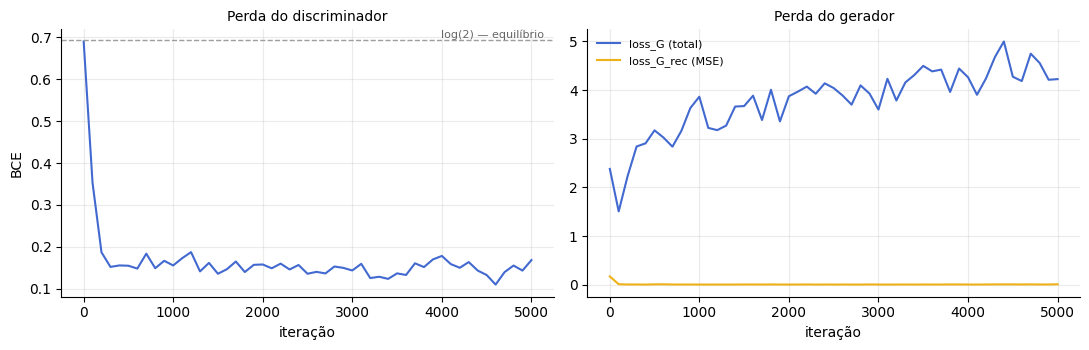

In [5]:
AZUL, LARANJA, CINZA = "#4269d0", "#efb118", "#9e9e9e"

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax = axes[0]
ax.plot(training_log["iteracao"], training_log["loss_D"], color=AZUL, lw=1.5)
ax.axhline(np.log(2), color=CINZA, lw=1, ls="--")
ax.annotate("log(2) — equilíbrio", xy=(0.98, np.log(2)), xycoords=("axes fraction", "data"),
            ha="right", va="bottom", fontsize=8, color="#666666")
ax.set_title("Perda do discriminador", fontsize=10)
ax.set_xlabel("iteração"); ax.set_ylabel("BCE")

ax = axes[1]
ax.plot(training_log["iteracao"], training_log["loss_G"], color=AZUL, lw=1.5, label="loss_G (total)")
ax.plot(training_log["iteracao"], training_log["loss_G_rec"], color=LARANJA, lw=1.5, label="loss_G_rec (MSE)")
ax.set_title("Perda do gerador", fontsize=10)
ax.set_xlabel("iteração")
ax.legend(frameon=False, fontsize=8)

for ax in axes:
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_FIG_DIR / "treino_inicial_loss.png", dpi=150, bbox_inches="tight")
plt.show()

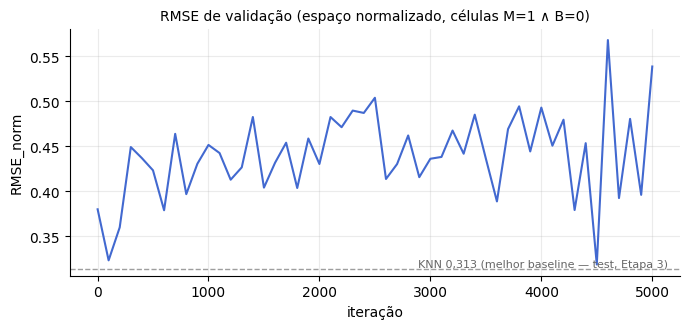

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(training_log["iteracao"], training_log["rmse_val"], color=AZUL, lw=1.5)
ax.axhline(0.313, color=CINZA, lw=1, ls="--")
ax.annotate("KNN 0,313 (melhor baseline — test, Etapa 3)", xy=(0.98, 0.313),
            xycoords=("axes fraction", "data"), ha="right", va="bottom",
            fontsize=8, color="#666666")
ax.set_title("RMSE de validação (espaço normalizado, células M=1 ∧ B=0)", fontsize=10)
ax.set_xlabel("iteração"); ax.set_ylabel("RMSE_norm")
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_FIG_DIR / "treino_inicial_rmse_val.png", dpi=150, bbox_inches="tight")
plt.show()

## Avaliação no val — protocolo da Etapa 3

Avaliamos a GAIN com o **mesmo** `baseline_utils.avaliar_baseline` da Etapa 3 (3 sementes `[42, 7, 2026]`, `miss_rate=0,20`, erro nas duas escalas). Como os números da `tabela_baselines.csv` foram medidos no **test**, reavaliamos aqui também o **KNN (campeão da Etapa 3) sobre o val** — comparação justa, mesmas células escondidas.

Atenção à leitura: o val tem só 34 coletas de 2023 (Nitrato com 12 observações, SST com 15, Coliformes com 2) — as métricas por variável são indicativas, não conclusivas. A decisão formal de aceite da etapa (bater o melhor baseline no val) acontece após o tuning, no notebook 2.

In [7]:
G.eval()

def predict_gain(X_obs, seed=None):
    m_obs = torch.tensor(X_obs.notna().to_numpy(dtype=np.float32))
    x_obs = torch.tensor(X_obs.fillna(0.0).to_numpy(dtype=np.float32))
    x_imp = gain.impute(G, x_obs, m_obs, ctx_val)
    return pd.DataFrame(x_imp.numpy(), columns=VARS, index=X_obs.index)

met_gain, pred_gain = bu.avaliar_baseline(
    "gain_inicial", predict_gain, df_val, mask_real_val,
    VARS, scalers, transform_params, seeds=[42, 7, 2026], miss_rate=0.20,
    generate_artificial_mask=generate_artificial_mask)

met_gain.groupby("variavel", sort=False)[["RMSE", "RMSE_norm", "n_avaliado"]].mean().round(4)

,RMSE,RMSE_norm,n_avaliado
variavel,,,
DBO,16.5633,0.3904,7.0000
OD,3.8116,0.4582,5.0000
Nitrato,0.0222,0.3667,1.3333
Nitrogênio Amoniacal Total,2.7255,0.4307,9.0000
Fósforo Total,1.1872,0.1569,5.6667
Condutividade,12262.6497,0.3821,5.6667
pH,0.3702,0.1645,8.0000
Turbidez,31.6284,0.2005,8.6667
Temperatura da Água,2.1231,0.2123,6.3333


In [8]:
# KNN (campeão da Etapa 3) avaliado nas MESMAS células do val, para comparação justa
from sklearn.impute import KNNImputer

FEATURES = VARS + CONTEXT_COLS
train_feat = df_train[FEATURES]

def predict_knn_val(X_obs, seed=None):
    imp = KNNImputer(n_neighbors=5, weights="distance")
    imp.fit(train_feat)
    out = imp.transform(pd.concat([X_obs, df_val[CONTEXT_COLS]], axis=1))
    return pd.DataFrame(out, columns=FEATURES, index=X_obs.index)[VARS]

met_knn_val, _ = bu.avaliar_baseline(
    "knn", predict_knn_val, df_val, mask_real_val,
    VARS, scalers, transform_params, seeds=[42, 7, 2026], miss_rate=0.20,
    generate_artificial_mask=generate_artificial_mask)

comp = pd.DataFrame({
    "GAIN_inicial": met_gain.groupby("variavel", sort=False)["RMSE_norm"].mean(),
    "KNN (val)":    met_knn_val.groupby("variavel", sort=False)["RMSE_norm"].mean(),
    "n_avaliado":   met_gain.groupby("variavel", sort=False)["n_avaliado"].sum(),
})
comp["GAIN vence"] = comp["GAIN_inicial"] < comp["KNN (val)"]

media_global = pd.DataFrame({
    "GAIN_inicial": [met_gain["RMSE_norm"].mean()],
    "KNN (val)":    [met_knn_val["RMSE_norm"].mean()],
}, index=["média global"])
print("RMSE_norm médio  —  GAIN: "
      f"{media_global.iloc[0, 0]:.4f}  |  KNN: {media_global.iloc[0, 1]:.4f}")
comp.round(4)

RMSE_norm médio  —  GAIN: 0.2964  |  KNN: 0.2742


,GAIN_inicial,KNN (val),n_avaliado,GAIN vence
variavel,,,,
DBO,0.3904,0.2980,21,False
OD,0.4582,0.3963,15,False
Nitrato,0.3667,0.3493,4,False
Nitrogênio Amoniacal Total,0.4307,0.3252,27,False
Fósforo Total,0.1569,0.1108,17,False
Condutividade,0.3821,0.2092,17,False
pH,0.1645,0.1749,24,True
Turbidez,0.2005,0.1869,26,False
Temperatura da Água,0.2123,0.1762,19,False


In [9]:
# Referência da Etapa 3 (medida no TEST — contexto, não comparação direta)
tabela_baselines = pd.read_csv(IN_TAB_BASELINES, encoding="utf-8")
melhor_test = (tabela_baselines
               .loc[tabela_baselines.groupby("variavel")["RMSE_norm_media"].idxmin()]
               [["variavel", "metodo", "RMSE_norm_media"]]
               .rename(columns={"metodo": "melhor_baseline_test",
                                "RMSE_norm_media": "RMSE_norm_test"})
               .set_index("variavel"))
comp.join(melhor_test).round(4)

,GAIN_inicial,KNN (val),n_avaliado,GAIN vence,melhor_baseline_test,RMSE_norm_test
variavel,,,,,,
DBO,0.3904,0.2980,21,False,knn,0.2088
OD,0.4582,0.3963,15,False,mice,0.2558
Nitrato,0.3667,0.3493,4,False,media_global,0.6194
Nitrogênio Amoniacal Total,0.4307,0.3252,27,False,missforest,0.4635
Fósforo Total,0.1569,0.1108,17,False,missforest,0.1621
Condutividade,0.3821,0.2092,17,False,mice,0.2109
pH,0.1645,0.1749,24,True,missforest,0.1982
Turbidez,0.2005,0.1869,26,False,mice,0.1728
Temperatura da Água,0.2123,0.1762,19,False,mice,0.2254


## Checkpoint

Persistimos G (já restaurado ao melhor estado de validação) **e** D (necessário se o notebook 2 quiser retomar o treino), os hiperparâmetros e as métricas — o checkpoint é autodescritivo.

In [10]:
ckpt = {
    "G_state": G.state_dict(),           # melhor estado por rmse_val (early stopping implícito)
    "D_state": D.state_dict(),
    "hp": hp,
    "vars": VARS,
    "context_cols": CONTEXT_COLS,
    "seed": SEED,
    "iteracao_melhor": int(melhor["iteracao"]),
    "rmse_val_melhor_norm": float(melhor["rmse_val"]),
    "rmse_val_protocolo_etapa3": float(met_gain["RMSE_norm"].mean()),
}
torch.save(ckpt, OUT_CKPT_DIR / "gain_inicial.pt")
print(f"checkpoint salvo: {OUT_CKPT_DIR / 'gain_inicial.pt'} "
      f"({(OUT_CKPT_DIR / 'gain_inicial.pt').stat().st_size / 1024:.0f} KB)")

checkpoint salvo: checkpoints\gain_inicial.pt (192 KB)


## Síntese final

### A GAIN convergiu?

**Parcialmente — e essa é a leitura honesta.** As perdas são estáveis e não-divergentes: `loss_D` oscila em ~0,13–0,17 (sem colapso para 0 — o D não domina; o nível abaixo de log(2) é esperado com `hint_rate=0,9`) e `loss_G_rec` estabiliza rápido em ~0,003. Mas a curva de `rmse_val` **não tem tendência sustentada de melhora**: cai cedo, oscila em torno de ~0,44 e o melhor ponto (0,3185, iteração 4500) é um mínimo pontual capturado pelo early stopping implícito. Diagnóstico: com os dados bem normalizados, o termo de reconstrução fica pequeno rápido e o gradiente do G passa a ser dominado (~100:1) pelo termo adversarial — que otimiza **realismo distribucional**, não RMSE. É o comportamento clássico de GAN-imputação sem ajuste fino, e define a agenda do notebook 2.

Nota de implementação já incorporada: a variante de hint do texto do paper (`0,5`) foi testada e **degrada** o treino neste dataset (`loss_G_adv ≈ 9`, RMSE de val piorando monotonicamente); a variante da implementação oficial (`H = R ⊙ M_ef`) é a usada aqui — detalhes no docstring de `gain.generate_hint`.

### Bate o melhor baseline?

Ainda não na média — mas **é comparável**, que é o critério deste notebook:

| Métrica (val, protocolo Etapa 3, 3 seeds) | GAIN inicial | KNN (val) |
|---|---:|---:|
| RMSE_norm médio | 0,296 | **0,274** |
| Variáveis onde vence (11) | 3 | 8 |

A GAIN inicial já vence o KNN em **pH** (0,164 vs 0,175), **Coliformes** (0,165 vs 0,187, n=3 — indicativo) e, com folga, em **Sólidos Suspensos Totais** (0,289 vs 0,573) — justamente a variável de cobertura crítica, onde o condicionamento em contexto compensa a escassez de vizinhos. Perde com margem em Condutividade (0,382 vs 0,209) e Nitrogênio Amoniacal (0,431 vs 0,325). Lembrete: val tem 34 coletas — números indicativos; a decisão formal acontece no notebook 2.

### Critério de aceite do notebook

- ✅ Checkpoint salvo (`checkpoints/gain_inicial.pt`, G restaurado ao melhor estado de validação).
- ✅ Curvas não-divergentes (D estável sem colapso; G estável).
- ✅ RMSE de val comparável ao melhor baseline (0,296 vs 0,274 — diferença de ~8%; não precisa superar nesta etapa).

### Vale a pena o hyperparameter search? Sim — com alavancas claras

Em ordem de expectativa de ganho para `02_hyperparam.ipynb`:

1. **`alpha` (10 → 50–100)**: o desequilíbrio adversarial/reconstrução (~100:1 no gradiente do G) é o problema dominante observado; `alpha` maior ancora o G na média condicional.
2. **Termo supervisionado nas células `(M=1, B=0)`**: o protocolo de mascaramento por batch dá verdade conhecida para células que o G vê como faltantes — um `beta · MSE` nelas otimiza exatamente o que o RMSE mede (e é a leitura literal do protocolo descrito em `06_mascaras.ipynb`).
3. **Conter a deriva do D**: `lr_d < lr_g` ou 1 passo de D a cada k passos de G.
4. **Grid do plano**: `hint_rate ∈ {0,7; 0,9}`, `alpha ∈ {1, 10, 100}`, profundidade ∈ {2, 3, 4}, batch ∈ {32, 64, 128} — com early stopping por paciência em vez de `n_iter` fixo (o mínimo pontual em 4500 mostra que a curva precisa ser vigiada, não cronometrada).

## Próximo notebook

`02_hyperparam.ipynb` — busca de hiperparâmetros com critério de aceite da etapa: **bater o melhor baseline no val**.